## 1. Geração da base específica para o modelo SVR

Nesta etapa, a base geral tratada é carregada a partir do arquivo `trafego_tratado.csv`. A partir dela, será construída uma base específica para o modelo SVR.

Como o SVR é um modelo supervisionado de regressão, a série temporal será reorganizada em formato tabular. Para evitar vazamento de informação, não serão utilizadas as variáveis `Sessões` e `Usuários ativos` do próprio dia previsto.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ============================================================
# 1. Leitura da base geral tratada
# ============================================================

df = pd.read_csv("../dados/trafego_tratado.csv")

# Converte a coluna de data
df["Data"] = pd.to_datetime(df["Data"])

# Garante ordenação cronológica
df = df.sort_values("Data").reset_index(drop=True)

print("Base geral tratada carregada com sucesso.")
print(f"Total de registros: {len(df)}")
print(f"Período: {df['Data'].min().date()} a {df['Data'].max().date()}")
print(df.head())
print(df.info())

Base geral tratada carregada com sucesso.
Total de registros: 1020
Período: 2023-07-01 a 2026-04-15
        Data  Sessões  Usuários ativos  Visualizações  dia_semana  \
0 2023-07-01     3109             2047           5566           6   
1 2023-07-02     3099             2083           5498           7   
2 2023-07-03    24119            13516          46786           1   
3 2023-07-04    23635            13335          44984           2   
4 2023-07-05    22217            13014          43559           3   

   fim_de_semana  mes  recesso_judiciario  feriado_nacional_fixo  carnaval  \
0              1    7                   0                      0         0   
1              1    7                   0                      0         0   
2              0    7                   0                      0         0   
3              0    7                   0                      0         0   
4              0    7                   0                      0         0   

   quarta_cinzas

## 2. Seleção das variáveis para a base do SVR

Nesta etapa, são selecionadas as variáveis que serão utilizadas na base específica do modelo SVR. Como o SVR é um modelo supervisionado de regressão, a série temporal precisa ser organizada em formato tabular, contendo a variável-alvo e os atributos explicativos.

Para evitar vazamento de informação, as variáveis `Sessões` e `Usuários ativos` não foram utilizadas como atributos explicativos, pois seus valores do próprio dia não seriam conhecidos em uma situação real de previsão. A variável a ser prevista será `Visualizações`, e as variáveis explicativas serão compostas por atributos temporais, variáveis de calendário, lags e médias móveis da própria série de visualizações.

In [2]:
df_svr = df.copy()

colunas_svr = [
    "Data",
    "Visualizações",
    "dia_semana",
    "fim_de_semana",
    "mes",
    "recesso_judiciario",
    "feriado_nacional_fixo",
    "carnaval",
    "quarta_cinzas",
    "sexta_paixao",
    "corpus_christi",
    "data_especifica_judiciario",
    "ponto_facultativo_emenda"
]

df_svr = df_svr[colunas_svr].copy()

print("Base inicial para SVR criada com sucesso.")
print(f"Total de registros: {len(df_svr)}")
print(f"Total de colunas: {df_svr.shape[1]}")
print(df_svr.head())
print(df_svr.info())

Base inicial para SVR criada com sucesso.
Total de registros: 1020
Total de colunas: 13
        Data  Visualizações  dia_semana  fim_de_semana  mes  \
0 2023-07-01           5566           6              1    7   
1 2023-07-02           5498           7              1    7   
2 2023-07-03          46786           1              0    7   
3 2023-07-04          44984           2              0    7   
4 2023-07-05          43559           3              0    7   

   recesso_judiciario  feriado_nacional_fixo  carnaval  quarta_cinzas  \
0                   0                      0         0              0   
1                   0                      0         0              0   
2                   0                      0         0              0   
3                   0                      0         0              0   
4                   0                      0         0              0   

   sexta_paixao  corpus_christi  data_especifica_judiciario  \
0             0               0

## 3. Criação de variáveis defasadas e médias móveis

Como o SVR não é um modelo temporal nativo, a série precisa ser convertida para um formato supervisionado. Para isso, foram criadas variáveis defasadas da variável `Visualizações`, permitindo que o modelo utilize valores anteriores da própria série para prever o valor atual.

Foram criados lags de 1, 7 e 30 dias, representando, respectivamente, o comportamento do dia anterior, da semana anterior e de um período mensal aproximado. Além disso, foram criadas médias móveis defasadas de 7 e 30 dias, com o objetivo de representar a tendência recente da série sem utilizar informação do próprio dia previsto.

In [3]:
# Lags da variável-alvo
df_svr["vis_lag_1"] = df_svr["Visualizações"].shift(1)
df_svr["vis_lag_7"] = df_svr["Visualizações"].shift(7)
df_svr["vis_lag_30"] = df_svr["Visualizações"].shift(30)

# Médias móveis defasadas da variável-alvo
# O shift(1) evita usar a informação do próprio dia previsto
df_svr["vis_mm_7"] = (
    df_svr["Visualizações"]
    .shift(1)
    .rolling(window=7)
    .mean()
)

df_svr["vis_mm_30"] = (
    df_svr["Visualizações"]
    .shift(1)
    .rolling(window=30)
    .mean()
)

print("Variáveis defasadas e médias móveis criadas com sucesso.")
print(df_svr[[
    "Data",
    "Visualizações",
    "vis_lag_1",
    "vis_lag_7",
    "vis_lag_30",
    "vis_mm_7",
    "vis_mm_30"
]].head(35))

Variáveis defasadas e médias móveis criadas com sucesso.
         Data  Visualizações  vis_lag_1  vis_lag_7  vis_lag_30      vis_mm_7  \
0  2023-07-01           5566        NaN        NaN         NaN           NaN   
1  2023-07-02           5498     5566.0        NaN         NaN           NaN   
2  2023-07-03          46786     5498.0        NaN         NaN           NaN   
3  2023-07-04          44984    46786.0        NaN         NaN           NaN   
4  2023-07-05          43559    44984.0        NaN         NaN           NaN   
5  2023-07-06          42866    43559.0        NaN         NaN           NaN   
6  2023-07-07          34495    42866.0        NaN         NaN           NaN   
7  2023-07-08           5441    34495.0     5566.0         NaN  31964.857143   
8  2023-07-09           5217     5441.0     5498.0         NaN  31947.000000   
9  2023-07-10          46533     5217.0    46786.0         NaN  31906.857143   
10 2023-07-11          45711    46533.0    44984.0         NaN 

## 4. Remoção de linhas sem histórico suficiente e salvamento da base SVR

A criação de lags e médias móveis gera valores ausentes nas primeiras observações da série, pois não há histórico anterior suficiente para calcular essas variáveis. Como esses registros não podem ser utilizados no treinamento do modelo SVR, as linhas com valores ausentes foram removidas.

Após essa etapa, a base final de modelagem do SVR foi salva em arquivo próprio, contendo a variável-alvo, os atributos temporais, as variáveis de calendário e as variáveis defasadas criadas a partir da série de visualizações.


In [4]:
print("Quantidade de valores ausentes antes da remoção:")
print(df_svr.isna().sum())

# Remove linhas com NaN geradas pelos lags e médias móveis
df_svr = df_svr.dropna().reset_index(drop=True)

# Salva a base final para SVR
df_svr.to_csv("../dados/trafego_svr_visualizacoes.csv", index=False)

print("\nBase final do SVR salva com sucesso.")
print("Arquivo salvo em: ../dados/trafego_svr_visualizacoes.csv")
print(f"Total de registros após remoção dos NaN: {len(df_svr)}")
print(f"Total de colunas: {df_svr.shape[1]}")
print(f"Período: {df_svr['Data'].min().date()} a {df_svr['Data'].max().date()}")

print("\nPrimeiras linhas da base final:")
print(df_svr.head())

print("\nInformações da base final:")
print(df_svr.info())

Quantidade de valores ausentes antes da remoção:
Data                           0
Visualizações                  0
dia_semana                     0
fim_de_semana                  0
mes                            0
recesso_judiciario             0
feriado_nacional_fixo          0
carnaval                       0
quarta_cinzas                  0
sexta_paixao                   0
corpus_christi                 0
data_especifica_judiciario     0
ponto_facultativo_emenda       0
vis_lag_1                      1
vis_lag_7                      7
vis_lag_30                    30
vis_mm_7                       7
vis_mm_30                     30
dtype: int64

Base final do SVR salva com sucesso.
Arquivo salvo em: ../dados/trafego_svr_visualizacoes.csv
Total de registros após remoção dos NaN: 990
Total de colunas: 18
Período: 2023-07-31 a 2026-04-15

Primeiras linhas da base final:
        Data  Visualizações  dia_semana  fim_de_semana  mes  \
0 2023-07-31          43139           1              0

## 5. Separação temporal entre treino e teste

Após a geração da base específica para o SVR, os dados foram divididos em conjuntos de treino e teste de forma sequencial, sem embaralhamento. Essa estratégia é necessária em séries temporais, pois preserva a ordem cronológica dos registros e evita que informações futuras sejam utilizadas no treinamento do modelo.

Neste experimento, os últimos 60 dias da série foram reservados para teste, enquanto os registros anteriores foram utilizados para treinamento.

In [5]:
dias_teste = 60

# Define a variável-alvo
y = df_svr["Visualizações"]

# Define as variáveis explicativas
# A coluna Data não entra diretamente no SVR
X = df_svr.drop(columns=["Data", "Visualizações"])

# Separação sequencial, sem embaralhamento
X_train = X.iloc[:-dias_teste].copy()
X_test = X.iloc[-dias_teste:].copy()

y_train = y.iloc[:-dias_teste].copy()
y_test = y.iloc[-dias_teste:].copy()

datas_test = df_svr["Data"].iloc[-dias_teste:].copy()

print("Separação treino/teste realizada com sucesso.")
print(f"Registros de treino: {len(X_train)}")
print(f"Registros de teste : {len(X_test)}")
print(f"Período de teste: {datas_test.min().date()} a {datas_test.max().date()}")

print("\nVariáveis explicativas utilizadas:")
print(X_train.columns.tolist())

Separação treino/teste realizada com sucesso.
Registros de treino: 930
Registros de teste : 60
Período de teste: 2026-02-15 a 2026-04-15

Variáveis explicativas utilizadas:
['dia_semana', 'fim_de_semana', 'mes', 'recesso_judiciario', 'feriado_nacional_fixo', 'carnaval', 'quarta_cinzas', 'sexta_paixao', 'corpus_christi', 'data_especifica_judiciario', 'ponto_facultativo_emenda', 'vis_lag_1', 'vis_lag_7', 'vis_lag_30', 'vis_mm_7', 'vis_mm_30']


## 6. Padronização das variáveis explicativas

O SVR é sensível à escala das variáveis, pois o algoritmo se baseia em medidas de distância e margem. Por isso, as variáveis explicativas foram padronizadas antes do treinamento.

A padronização foi ajustada apenas com os dados de treino e depois aplicada ao conjunto de teste. Esse procedimento evita vazamento de informação, pois impede que estatísticas do conjunto de teste influenciem o treinamento do modelo.

In [6]:
scaler = StandardScaler()

# Ajusta o scaler apenas nos dados de treino
X_train_scaled = scaler.fit_transform(X_train)

# Aplica a mesma transformação nos dados de teste
X_test_scaled = scaler.transform(X_test)

print("Padronização realizada com sucesso.")
print(f"Formato de X_train_scaled: {X_train_scaled.shape}")
print(f"Formato de X_test_scaled : {X_test_scaled.shape}")

Padronização realizada com sucesso.
Formato de X_train_scaled: (930, 16)
Formato de X_test_scaled : (60, 16)


## 7. Treinamento e avaliação preliminar do SVR

Nesta etapa, o modelo SVR é treinado com os dados padronizados do conjunto de treino. Foi utilizado o kernel RBF, configuração comum para problemas de regressão não linear.

Após o treinamento, o modelo é aplicado ao conjunto de teste, composto pelos últimos 60 dias da série. O desempenho é avaliado pelas métricas RMSE, MAE, MAPE e R², permitindo comparação posterior com os demais algoritmos testados.

In [7]:
def calcular_mape(y_true, y_pred):
    """Calcula o MAPE em porcentagem."""
    y_true = np.array(y_true, dtype=float)
    y_pred = np.array(y_pred, dtype=float)

    mascara = y_true != 0
    return np.mean(np.abs((y_true[mascara] - y_pred[mascara]) / y_true[mascara])) * 100


# Modelo SVR preliminar
modelo_svr = SVR(
    kernel="rbf",
    C=100,
    epsilon=0.1,
    gamma="scale"
)

# Treinamento
modelo_svr.fit(X_train_scaled, y_train)

# Previsão no conjunto de teste
y_pred_svr = modelo_svr.predict(X_test_scaled)

# Cálculo das métricas
rmse_svr = np.sqrt(mean_squared_error(y_test, y_pred_svr))
mae_svr = mean_absolute_error(y_test, y_pred_svr)
mape_svr = calcular_mape(y_test, y_pred_svr)
r2_svr = r2_score(y_test, y_pred_svr)

print("=" * 60)
print("AVALIAÇÃO SVR - ÚLTIMOS 60 DIAS")
print("=" * 60)
print(f"RMSE: {rmse_svr:.2f}")
print(f"MAE : {mae_svr:.2f}")
print(f"MAPE: {mape_svr:.2f}%")
print(f"R²  : {r2_svr:.4f}")

AVALIAÇÃO SVR - ÚLTIMOS 60 DIAS
RMSE: 8933.38
MAE : 6857.27
MAPE: 91.29%
R²  : 0.7010


## 8. Visualização dos valores reais e previstos pelo SVR

Após o treinamento preliminar do SVR, foi gerado um gráfico comparando os valores reais e previstos no conjunto de teste. Essa visualização permite identificar se o modelo acompanha o comportamento geral da série e em quais períodos apresenta maiores desvios.

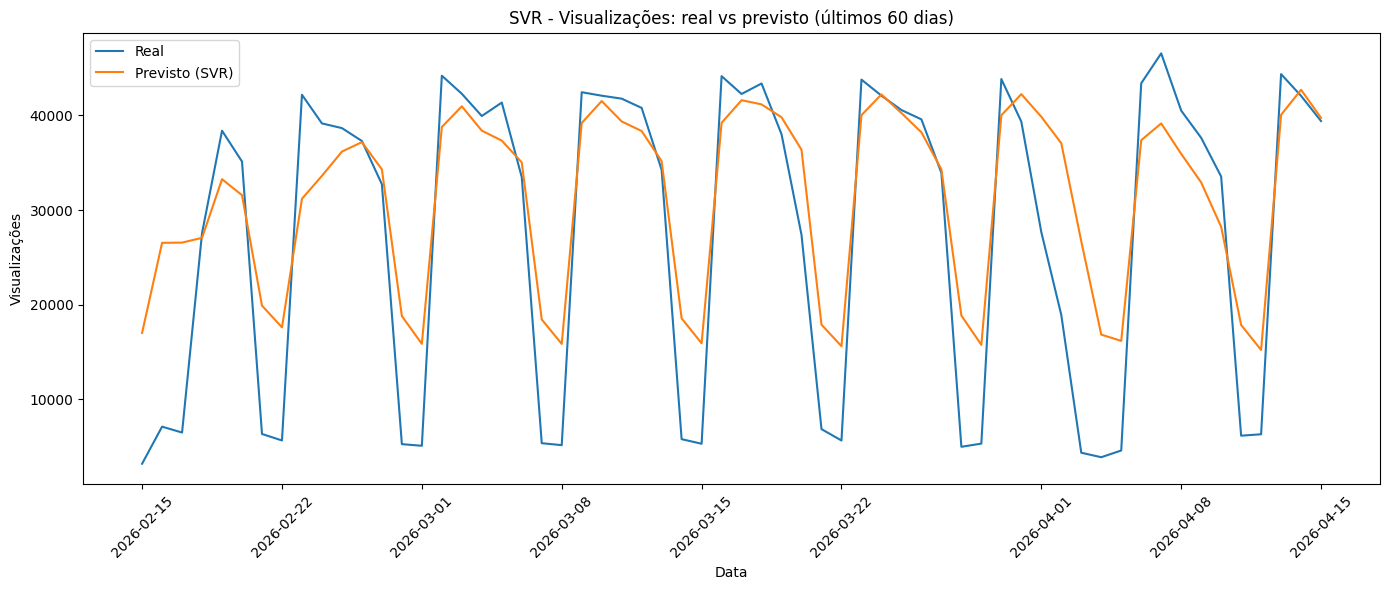

In [8]:
plt.figure(figsize=(14, 6))
plt.plot(datas_test, y_test.values, label="Real")
plt.plot(datas_test, y_pred_svr, label="Previsto (SVR)")

plt.title("SVR - Visualizações: real vs previsto (últimos 60 dias)")
plt.xlabel("Data")
plt.ylabel("Visualizações")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 9. Ajuste de hiperparâmetros do SVR

O primeiro modelo SVR foi treinado com parâmetros preliminares. Como o desempenho inicial apresentou erro elevado, especialmente nos dias de menor tráfego, foi realizado um ajuste de hiperparâmetros.

Para isso, foi utilizada uma validação cruzada temporal apenas sobre o conjunto de treino, preservando a ordem dos dados. Foram testados diferentes valores de `C`, `epsilon` e `gamma`, parâmetros que controlam, respectivamente, a penalização dos erros, a tolerância da margem e a influência dos pontos no kernel RBF.

In [9]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV

# ============================================================
# 9. Ajuste de hiperparâmetros do SVR
# ============================================================

pipeline_svr = Pipeline([
    ("scaler", StandardScaler()),
    ("svr", SVR(kernel="rbf"))
])

param_grid = {
    "svr__C": [1000, 5000, 10000, 50000],
    "svr__epsilon": [100, 500, 1000, 2000],
    "svr__gamma": ["scale", 0.001, 0.01, 0.1]
}

tscv = TimeSeriesSplit(n_splits=5)

grid_svr = GridSearchCV(
    estimator=pipeline_svr,
    param_grid=param_grid,
    scoring="neg_mean_absolute_error",
    cv=tscv,
    n_jobs=-1,
    verbose=1
)

grid_svr.fit(X_train, y_train)

print("Melhores hiperparâmetros encontrados:")
print(grid_svr.best_params_)

print("\nMelhor MAE médio na validação cruzada:")
print(f"{-grid_svr.best_score_:.2f}")

Fitting 5 folds for each of 64 candidates, totalling 320 fits
Melhores hiperparâmetros encontrados:
{'svr__C': 50000, 'svr__epsilon': 100, 'svr__gamma': 0.01}

Melhor MAE médio na validação cruzada:
3402.00


## 10. Treinamento do SVR com os melhores hiperparâmetros

Após o ajuste de hiperparâmetros, o modelo SVR foi treinado novamente utilizando a melhor combinação encontrada na validação cruzada temporal. Em seguida, o modelo ajustado foi aplicado ao conjunto de teste, composto pelos últimos 60 dias da série, para avaliação final do desempenho.

In [10]:
# Recupera o melhor modelo encontrado no GridSearchCV
melhor_modelo_svr = grid_svr.best_estimator_

# Previsão no conjunto de teste
y_pred_svr_otimizado = melhor_modelo_svr.predict(X_test)

# Cálculo das métricas no conjunto de teste
rmse_svr_otimizado = np.sqrt(mean_squared_error(y_test, y_pred_svr_otimizado))
mae_svr_otimizado = mean_absolute_error(y_test, y_pred_svr_otimizado)
mape_svr_otimizado = calcular_mape(y_test, y_pred_svr_otimizado)
r2_svr_otimizado = r2_score(y_test, y_pred_svr_otimizado)

print("=" * 60)
print("AVALIAÇÃO SVR OTIMIZADO - ÚLTIMOS 60 DIAS")
print("=" * 60)
print(f"Melhores parâmetros: {grid_svr.best_params_}")
print(f"RMSE: {rmse_svr_otimizado:.2f}")
print(f"MAE : {mae_svr_otimizado:.2f}")
print(f"MAPE: {mape_svr_otimizado:.2f}%")
print(f"R²  : {r2_svr_otimizado:.4f}")

AVALIAÇÃO SVR OTIMIZADO - ÚLTIMOS 60 DIAS
Melhores parâmetros: {'svr__C': 50000, 'svr__epsilon': 100, 'svr__gamma': 0.01}
RMSE: 4088.01
MAE : 2499.68
MAPE: 12.60%
R²  : 0.9374


## 11. Visualização do SVR otimizado

Após o ajuste de hiperparâmetros, foi gerado um novo gráfico comparando os valores reais e previstos pelo SVR otimizado no conjunto de teste. Essa visualização permite verificar se o modelo ajustado acompanha melhor os picos e quedas da série, especialmente em dias de menor tráfego.

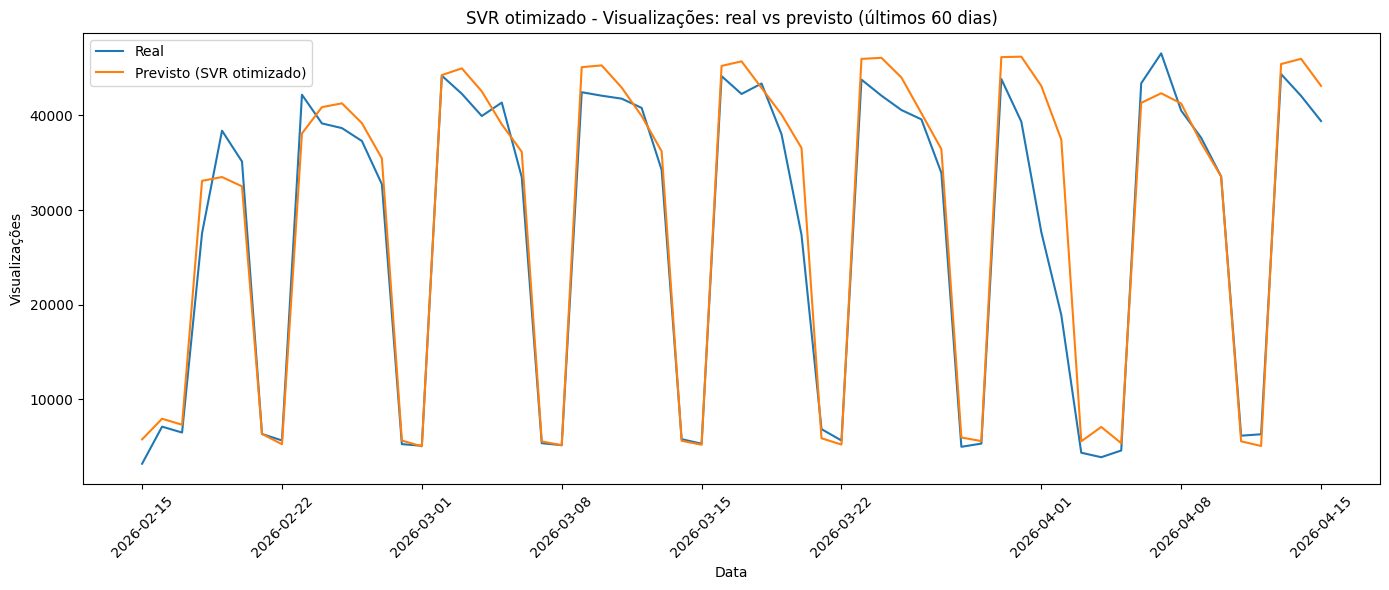

In [11]:
plt.figure(figsize=(14, 6))
plt.plot(datas_test, y_test.values, label="Real")
plt.plot(datas_test, y_pred_svr_otimizado, label="Previsto (SVR otimizado)")

plt.title("SVR otimizado - Visualizações: real vs previsto (últimos 60 dias)")
plt.xlabel("Data")
plt.ylabel("Visualizações")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 12. Salvamento das métricas e previsões do SVR

Ao final da execução, foram salvas as métricas de desempenho do modelo SVR e as previsões realizadas para o conjunto de teste. Esses arquivos serão utilizados posteriormente na etapa de comparação entre os algoritmos avaliados.

In [12]:
# Tabela com métricas do SVR preliminar e do SVR otimizado
metricas_svr = pd.DataFrame({
    "modelo": ["SVR preliminar", "SVR otimizado"],
    "rmse": [rmse_svr, rmse_svr_otimizado],
    "mae": [mae_svr, mae_svr_otimizado],
    "mape": [mape_svr, mape_svr_otimizado],
    "r2": [r2_svr, r2_svr_otimizado]
})

metricas_svr.to_csv("../dados/metricas_svr.csv", index=False)

# Tabela com previsões do modelo otimizado
previsao_svr = pd.DataFrame({
    "Data": datas_test.values,
    "real": y_test.values,
    "previsto_svr": y_pred_svr_otimizado
})

previsao_svr["erro"] = previsao_svr["real"] - previsao_svr["previsto_svr"]
previsao_svr["erro_absoluto"] = abs(previsao_svr["erro"])
previsao_svr["erro_percentual_abs"] = (
    previsao_svr["erro_absoluto"] / previsao_svr["real"]
) * 100

previsao_svr.to_csv("../dados/previsao_svr_visualizacoes.csv", index=False)

print("Arquivos salvos com sucesso:")
print("../dados/metricas_svr.csv")
print("../dados/previsao_svr_visualizacoes.csv")

print("\nMétricas do SVR:")
print(metricas_svr)

print("\nPrimeiras previsões:")
print(previsao_svr.head())

Arquivos salvos com sucesso:
../dados/metricas_svr.csv
../dados/previsao_svr_visualizacoes.csv

Métricas do SVR:
           modelo         rmse          mae       mape        r2
0  SVR preliminar  8933.384643  6857.272027  91.289314  0.700955
1   SVR otimizado  4088.013688  2499.677784  12.603153  0.937378

Primeiras previsões:
        Data   real  previsto_svr         erro  erro_absoluto  \
0 2026-02-15   3182   5755.759510 -2573.759510    2573.759510   
1 2026-02-16   7101   7939.658124  -838.658124     838.658124   
2 2026-02-17   6479   7304.214628  -825.214628     825.214628   
3 2026-02-18  27554  33081.020017 -5527.020017    5527.020017   
4 2026-02-19  38385  33484.995601  4900.004399    4900.004399   

   erro_percentual_abs  
0            80.884963  
1            11.810423  
2            12.736759  
3            20.058866  
4            12.765415  
